# Customer Churn Prediction

**Pipeline:** EDA → Preprocessing → 5 Models đơn lẻ → Voting Ensemble → SHAP Explainability

**Dataset:** IBM Telco Customer Churn (7.043 khách hàng, 21 features)

---
| Pha | Nội dung |
|-----|----------|
| 1 | Cài đặt & Load data |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Tiền xử lý & Feature Engineering |
| 4 | Huấn luyện 5 mô hình đơn lẻ |
| 5 | Đánh giá & So sánh models |
| 6 | Voting Ensemble (Hard + Soft) |
| 7 | Giải thích mô hình với SHAP |
| 8 | Dự đoán khách hàng mới |

## PHA 1 — CÀI ĐẶT THƯ VIỆN

In [1]:
!pip install shap imbalanced-learn xgboost lightgbm --quiet
print('✅ Đã cài xong tất cả thư viện')

✅ Đã cài xong tất cả thư viện


In [2]:
# ============================================================
# IMPORT & SEED
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import shap
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

COLORS = {'churn': '#E8593C', 'no_churn': '#1D9E75', 'accent': '#3266ad'}
print('✅ Import xong, seed =', SEED)

✅ Import xong, seed = 42


In [3]:
# ============================================================
# LOAD DATA
# ============================================================
from google.colab import files

print('Vui lòng upload file CSV của bạn:')
uploaded = files.upload()

# Lấy tên file đầu tiên được upload
file_name = next(iter(uploaded))
print(f'✅ Đã upload file: {file_name}')

def load_data(url_or_path):
    """Load dataset từ URL hoặc file local."""
    df = pd.read_csv(url_or_path)
    return df

def validate_schema(df):
    """In thông tin cơ bản về dataset."""
    print(f'Shape: {df.shape[0]:,} hàng × {df.shape[1]} cột')

    print(f'Churn rate: {df["Churn"].value_counts(normalize=True)[1]:.1%}')

    missing = df.isnull().sum()
    if missing.sum() > 0:
        print('\nMissing values:')
        print(missing[missing > 0])
    else:
        print('Không có missing values')
    return df

df_raw = load_data(file_name)
validate_schema(df_raw)
df_raw.head(5)

Vui lòng upload file CSV của bạn:


Saving Dataset.csv to Dataset.csv
✅ Đã upload file: Dataset.csv
Shape: 66,736 hàng × 30 cột
Churn rate: 35.0%
Không có missing values


,Customer_number,Client_gender,Age,Staff_VIB,Tenure,SMS,Verify_method,EB_register_channel,No_Activity_Name,Type_Transactions,...,Avg_TermDeposit_Balance,Max_TermDeposit_Balance,Min_TermDeposit_Balance,No_Loan,Avg_Loan_Balance,Max_Loan_Balance,Min_Loan_Balance,No_CC,No_DC,Churn
0,1,0,28.215615,1,19.918800,0,1,0,1,7,...,2.778291e+07,4.297395e+07,8.143434e+05,4,2.134182e+07,3.628493e+07,6.139306e+06,1,0,0
1,2,1,28.744430,0,8.076794,1,0,0,11,3,...,1.020093e+06,1.323149e+06,2.380507e+04,0,2.519806e+06,3.799277e+06,7.046202e+05,0,2,1
2,3,0,35.406264,0,11.641340,0,1,0,8,6,...,3.301211e+06,4.550049e+06,9.072812e+05,0,1.389617e+07,2.167573e+07,2.676174e+06,1,0,1
3,4,1,31.186114,0,22.163064,1,1,2,13,5,...,5.901529e+06,1.177052e+07,6.160315e+05,4,2.126704e+07,2.609320e+07,1.665175e+06,2,0,0
4,5,0,42.555118,0,21.800850,0,0,0,6,8,...,3.607055e+07,4.406522e+07,5.763604e+06,1,4.620992e+07,6.357315e+07,1.049171e+07,0,0,0


## 📊 Pha 2 — Exploratory Data Analysis (EDA)

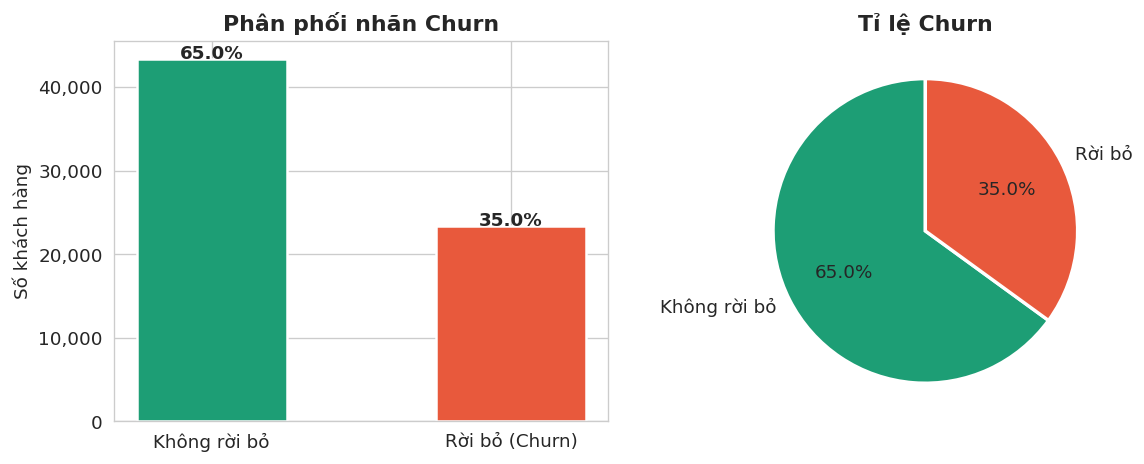

⚠️  Dữ liệu mất cân bằng: 35.0% churn → cần SMOTE ở bước preprocessing


In [4]:
def plot_churn_distribution(df):
    """Phân phối nhãn Churn: count + pie chart."""
    counts = df['Churn'].value_counts()
    pct    = df['Churn'].value_counts(normalize=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Bar
    bars = axes[0].bar(
        ['Không rời bỏ', 'Rời bỏ (Churn)'],
        counts.values,
        color=[COLORS['no_churn'], COLORS['churn']],
        edgecolor='white', linewidth=1.5, width=0.5
    )
    for bar, p in zip(bars, pct.values):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 60,
                     f'{p:.1f}%', ha='center', fontweight='bold')
    axes[0].set_title('Phân phối nhãn Churn', fontweight='bold')
    axes[0].set_ylabel('Số khách hàng')
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    # Pie
    axes[1].pie(
        counts.values,
        labels=['Không rời bỏ', 'Rời bỏ'],
        colors=[COLORS['no_churn'], COLORS['churn']],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    axes[1].set_title('Tỉ lệ Churn', fontweight='bold')

    plt.tight_layout()
    plt.savefig('eda_churn_dist.png', bbox_inches='tight')
    plt.show()
    print(f'⚠️  Dữ liệu mất cân bằng: {pct[1]:.1f}% churn → cần SMOTE ở bước preprocessing')

plot_churn_distribution(df_raw)

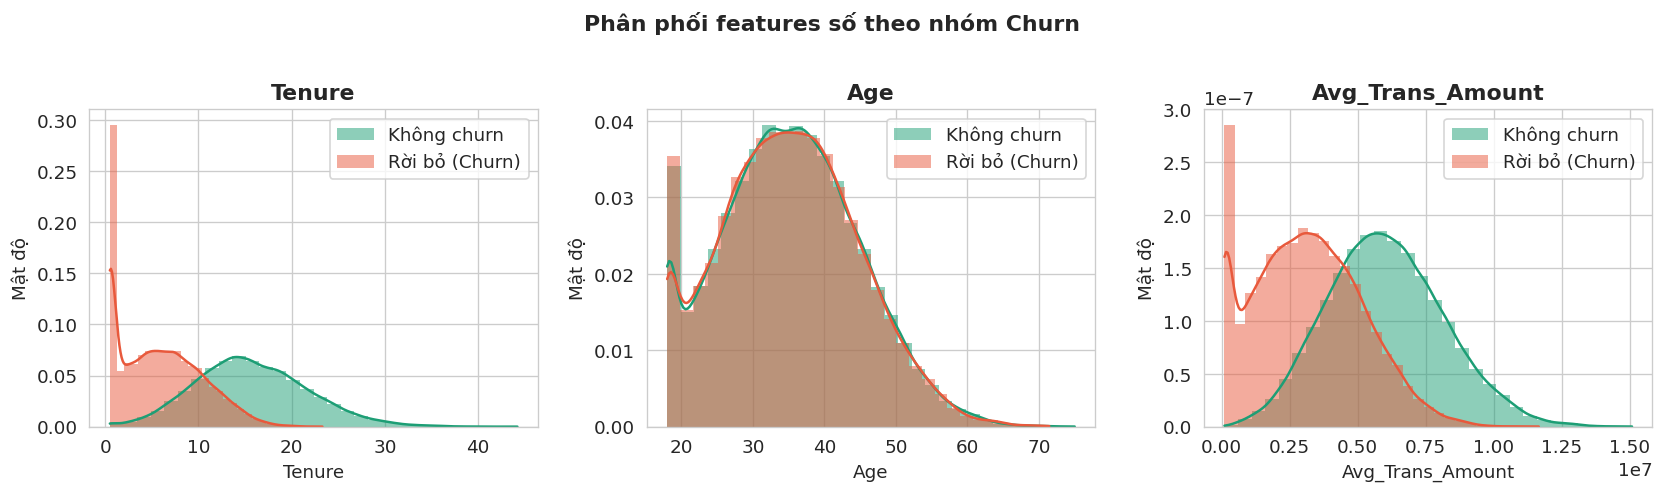

In [5]:
def plot_numeric_features(df):
    """Histogram + KDE của các features số, phân tách theo Churn."""
    num_cols = ['Tenure', 'Age', 'Avg_Trans_Amount']
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    for ax, col in zip(axes, num_cols):
        for label_val, label_str, color in [(0, 'Không churn', COLORS['no_churn']), (1, 'Rời bỏ (Churn)', COLORS['churn'])]:
            subset = df[df['Churn'] == label_val][col].dropna()

            sns.histplot(
                subset,
                bins=30,
                kde=True,          # Bật đường cong mật độ KDE
                color=color,
                label=label_str,
                ax=ax,
                stat="density",    # Chuẩn hóa về dạng mật độ
                alpha=0.5,
                edgecolor='none'
            )

        ax.set_title(col, fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Mật độ')
        ax.legend()

    plt.suptitle('Phân phối features số theo nhóm Churn', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('eda_numeric.png', bbox_inches='tight')
    plt.show()

plot_numeric_features(df_raw)

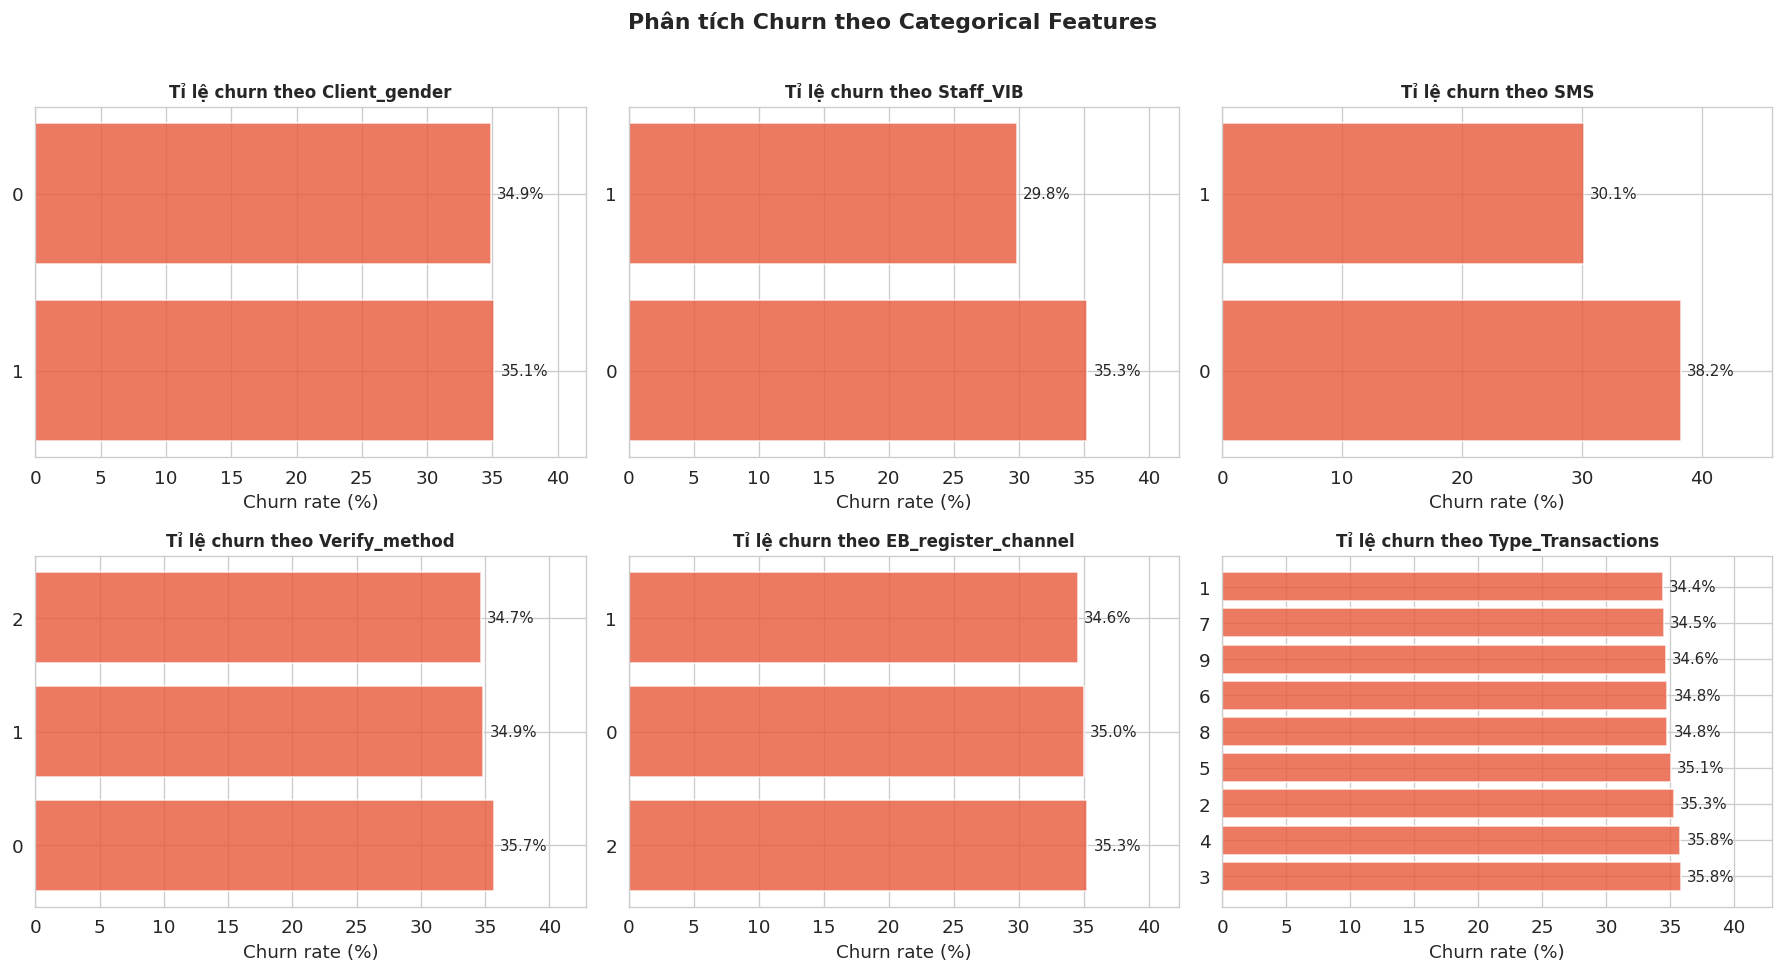

In [6]:
def plot_categorical_features(df):
    """Tỉ lệ churn theo các categorical features quan trọng."""

    # 1. Cập nhật 6 biến phân loại quan trọng trong bộ dữ liệu ngân hàng
    cat_cols = ['Client_gender', 'Staff_VIB', 'SMS',
                'Verify_method', 'EB_register_channel', 'Type_Transactions']

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for ax, col in zip(axes, cat_cols):
        # 2. Sửa điều kiện đếm churn: x == 1 thay vì x == 'Yes'
        churn_rate = (df.groupby(col)['Churn']
                        .apply(lambda x: (x == 1).mean() * 100)
                        .sort_values(ascending=False))

        y_labels = churn_rate.index.astype(str)

        bars = ax.barh(y_labels, churn_rate.values,
                       color=COLORS['churn'], alpha=0.8, edgecolor='white')

        for bar, val in zip(bars, churn_rate.values):
            ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=9)

        ax.set_title(f'Tỉ lệ churn theo {col}', fontweight='bold', fontsize=10)
        ax.set_xlabel('Churn rate (%)')

        # Xử lý ngoại lệ nếu max = 0 để tránh lỗi giới hạn trục x
        max_val = churn_rate.max()
        ax.set_xlim(0, (max_val * 1.2) if max_val > 0 else 100)

    plt.suptitle('Phân tích Churn theo Categorical Features', fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('eda_categorical.png', bbox_inches='tight')
    plt.show()

# Gọi hàm
plot_categorical_features(df_raw)

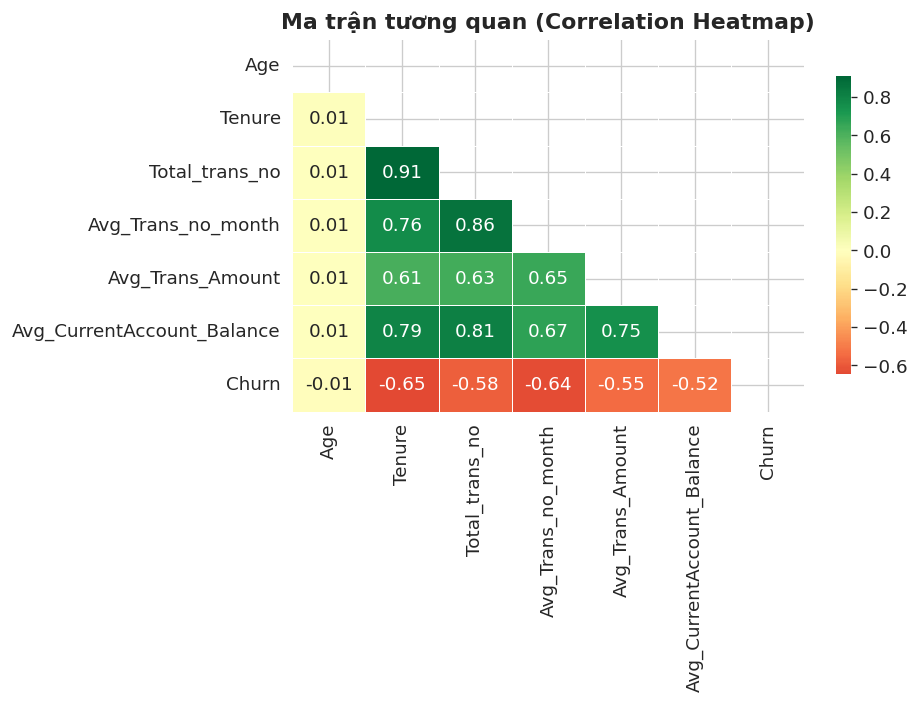

In [7]:
def plot_correlation_heatmap(df):
    """Correlation heatmap của các features số và biến mục tiêu (Churn)."""

    # 1. Định nghĩa các cột số học (Continuous) cần xét tương quan
    num_cols = [
        'Age',
        'Tenure',
        'Total_trans_no',
        'Avg_Trans_no_month',
        'Avg_Trans_Amount',
        'Avg_CurrentAccount_Balance',
        'Churn'
    ]

    # 2. Tạo dataframe chỉ chứa các cột số đã chọn
    num_df = df[num_cols].dropna()

    # 3. Vẽ ma trận tương quan
    fig, ax = plt.subplots(figsize=(8, 6))
    mask = np.triu(np.ones_like(num_df.corr(), dtype=bool))

    sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, mask=mask, ax=ax, linewidths=0.5,
                cbar_kws={'shrink': 0.8})

    ax.set_title('Ma trận tương quan (Correlation Heatmap)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_correlation.png', bbox_inches='tight')
    plt.show()

# Gọi hàm
plot_correlation_heatmap(df_raw)

## 🔧 Pha 3 — Tiền xử lý & Feature Engineering

In [8]:
# 1. Đọc dữ liệu
df = pd.read_csv('Dataset.csv')

# 2. Loại bỏ cột định danh khách hàng
if 'Customer_number' in df.columns:
    df.drop(columns=['Customer_number'], inplace=True)

# 3. Tách Features (X) và Target (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# 4. Chia tập dữ liệu Train/Test
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Áp dụng SMOTE để cân bằng dữ liệu (CHỈ ÁP DỤNG TRÊN TẬP TRAIN)
print(f"--- Trạng thái biến mục tiêu (y_train) TRƯỚC khi SMOTE ---")
print(y_train_raw.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train = smote.fit_resample(X_train_raw, y_train_raw)

print(f"\n--- Trạng thái biến mục tiêu (y_train) SAU khi SMOTE ---")
print(y_train.value_counts())

# 6. Chuẩn hóa dữ liệu (Scaling)
scaler = StandardScaler()

# Fit và transform scaler trên tập train đã được thêm dữ liệu tổng hợp (SMOTE)
X_train_scaled = scaler.fit_transform(X_train_smote)
# Chỉ transform (không fit) trên tập test nguyên bản
X_test_scaled = scaler.transform(X_test_raw)

# 7. Chuyển ngược về DataFrame để giữ tên cột (Phục vụ vẽ biểu đồ SHAP ở Pha 7)
X_train = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\n--- TIỀN XỬ LÝ DỮ LIỆU HOÀN TẤT ---")
print(f"Kích thước tập huấn luyện (Đã SMOTE) : {X_train.shape[0]:,} hàng × {X_train.shape[1]} cột")
print(f"Kích thước tập kiểm thử   (Giữ nguyên): {X_test.shape[0]:,} hàng × {X_test.shape[1]} cột")

--- Trạng thái biến mục tiêu (y_train) TRƯỚC khi SMOTE ---
Churn
0    34702
1    18686
Name: count, dtype: int64

--- Trạng thái biến mục tiêu (y_train) SAU khi SMOTE ---
Churn
1    34702
0    34702
Name: count, dtype: int64

--- TIỀN XỬ LÝ DỮ LIỆU HOÀN TẤT ---
Kích thước tập huấn luyện (Đã SMOTE) : 69,404 hàng × 28 cột
Kích thước tập kiểm thử   (Giữ nguyên): 13,348 hàng × 28 cột


## 🤖 Pha 4 — Huấn luyện 5 Mô Hình Đơn Lẻ

In [9]:
# Định nghĩa 5 models
MODELS = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, random_state=42, n_jobs=-1
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=10, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=7, min_samples_leaf=5,
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1
    ),
    'SVM': SVC(
        C=1.0, kernel='rbf', probability=True, random_state=42
    ),
}

def train_all_models(models, X_train, y_train):
    """Huấn luyện tất cả models, trả về dict trained models."""
    trained = {}
    for name, model in models.items():
        print(f'  Đang train: {name}...', end=' ')
        model.fit(X_train, y_train)
        trained[name] = model
        print('✅')
    return trained

print('🚀 Bắt đầu training...')
trained_models = train_all_models(MODELS, X_train, y_train)
print('\n✅ Training hoàn tất!')

🚀 Bắt đầu training...
  Đang train: Logistic Regression... ✅
  Đang train: Decision Tree... ✅
  Đang train: Random Forest... ✅
  Đang train: XGBoost... ✅
  Đang train: SVM... ✅

✅ Training hoàn tất!


## 📈 Pha 5 — Đánh Giá & So Sánh Models

📊 Bảng so sánh models (sắp xếp theo AUC-ROC):


,Accuracy,Precision,Recall,F1,AUC-ROC
Model,,,,,
XGBoost,0.9099,0.8498,0.9022,0.8752,0.9738
Logistic Regression,0.9112,0.8529,0.9020,0.8767,0.9735
SVM,0.9093,0.8537,0.8940,0.8734,0.9711
Random Forest,0.8947,0.8155,0.9037,0.8573,0.9639
Decision Tree,0.8870,0.8067,0.8906,0.8466,0.9574


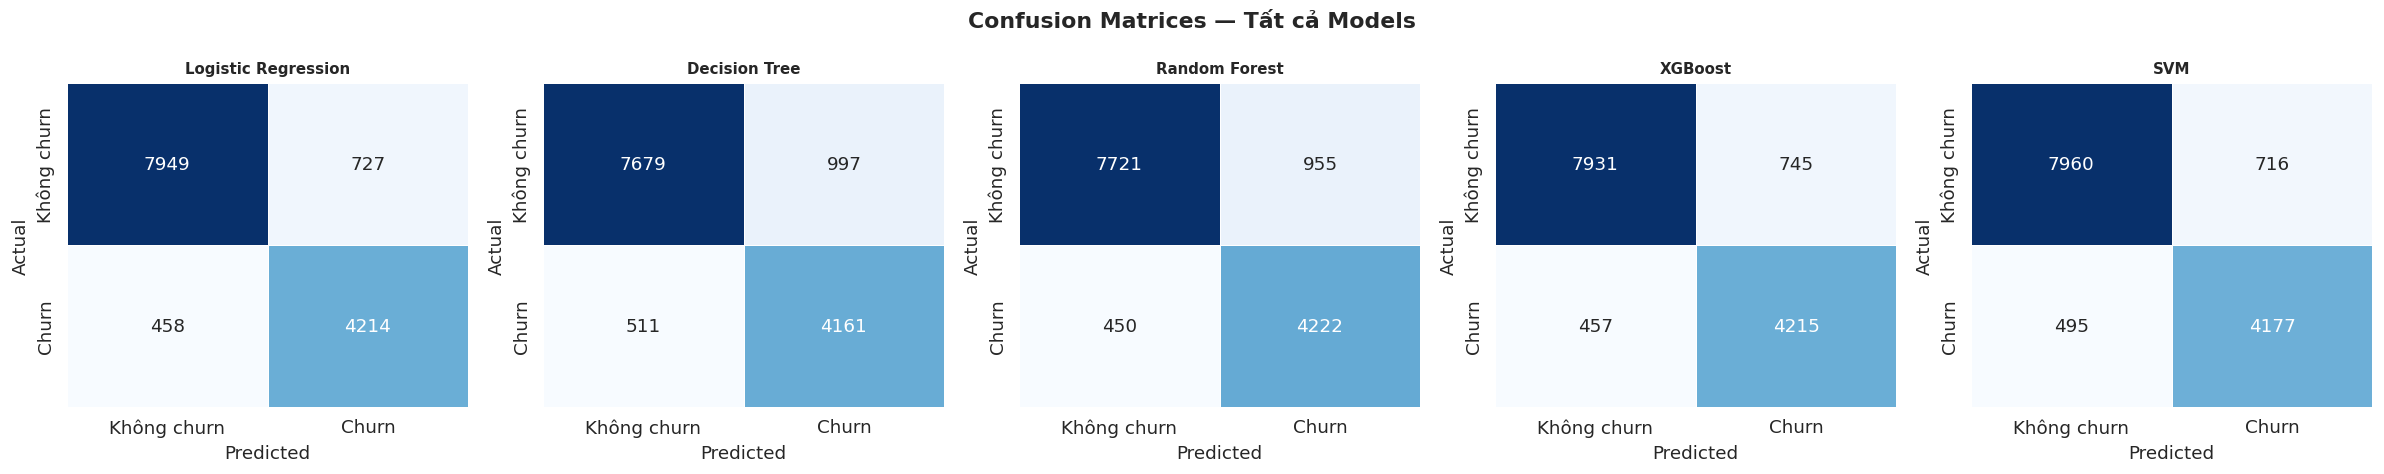

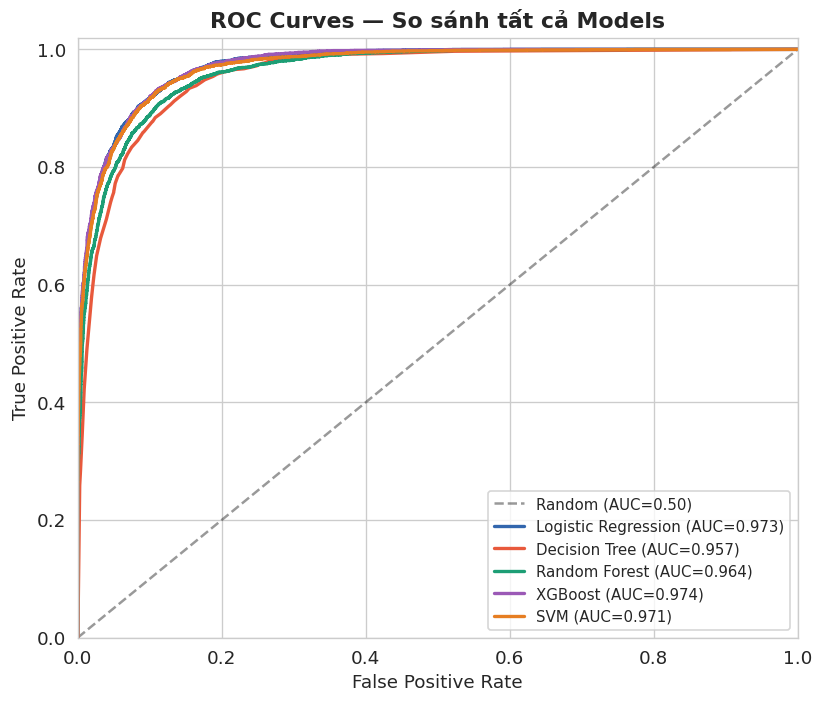

In [10]:
def evaluate_model(model, X_test, y_test, model_name='Model'):
    """Tính đầy đủ metrics cho 1 model."""
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    metrics = {
        'Model'     : model_name,
        'Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'Precision' : round(precision_score(y_test, y_pred), 4),
        'Recall'    : round(recall_score(y_test, y_pred), 4),
        'F1'        : round(f1_score(y_test, y_pred), 4),
        'AUC-ROC'   : round(roc_auc_score(y_test, y_proba), 4) if y_proba is not None else np.nan,
    }
    return metrics

def compare_models_table(trained_models, X_test, y_test):
    """Bảng so sánh tất cả models."""
    results = [evaluate_model(m, X_test, y_test, name)
               for name, m in trained_models.items()]
    df_res = pd.DataFrame(results).set_index('Model')
    df_res = df_res.sort_values('AUC-ROC', ascending=False)

    # Highlight giá trị tốt nhất
    styled = (df_res.style
               .highlight_max(axis=0, color='#c8f7c5')
               .format('{:.4f}'))
    return df_res, styled

def plot_confusion_matrices(trained_models, X_test, y_test):
    """Vẽ confusion matrix cho tất cả models."""
    n = len(trained_models)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    for ax, (name, model) in zip(axes, trained_models.items()):
        cm = confusion_matrix(y_test, model.predict(X_test))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    linewidths=0.5, cbar=False,
                    xticklabels=['Không churn', 'Churn'],
                    yticklabels=['Không churn', 'Churn'])
        ax.set_title(name, fontweight='bold', fontsize=9)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    plt.suptitle('Confusion Matrices — Tất cả Models', fontweight='bold')
    plt.tight_layout()
    plt.savefig('confusion_matrices.png', bbox_inches='tight')
    plt.show()

def plot_roc_curves(trained_models, X_test, y_test):
    """ROC curves tất cả models trên 1 biểu đồ."""
    palette = ['#3266ad', '#E8593C', '#1D9E75', '#9b59b6', '#e67e22']
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Random (AUC=0.50)')

    for (name, model), color in zip(trained_models.items(), palette):
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            auc = roc_auc_score(y_test, y_prob)
            ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves — So sánh tất cả Models', fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    plt.tight_layout()
    plt.savefig('roc_curves.png', bbox_inches='tight')
    plt.show()

results_df, styled_table = compare_models_table(trained_models, X_test, y_test)
print('📊 Bảng so sánh models (sắp xếp theo AUC-ROC):')
display(styled_table)

plot_confusion_matrices(trained_models, X_test, y_test)
plot_roc_curves(trained_models, X_test, y_test)

In [11]:
def cross_validate_all(trained_models, X_train, y_train, cv=5):
    """Cross-validation 5-fold cho tất cả models."""
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)
    cv_results = {}
    print(f'Cross-validation {cv}-fold trên tập train:')
    for name, model in trained_models.items():
        scores = cross_val_score(model, X_train, y_train,
                                  cv=skf, scoring='roc_auc', n_jobs=-1)
        cv_results[name] = scores
        print(f'  {name:25s}: {scores.mean():.4f} ± {scores.std():.4f}')
    return cv_results

cv_results = cross_validate_all(trained_models, X_train, y_train)

Cross-validation 5-fold trên tập train:
  Logistic Regression      : 0.9796 ± 0.0008
  Decision Tree            : 0.9647 ± 0.0012
  Random Forest            : 0.9701 ± 0.0015
  XGBoost                  : 0.9808 ± 0.0008
  SVM                      : 0.9800 ± 0.0007


## 🗳️ Pha 6 — Voting Ensemble (Hard & Soft)

In [12]:
def build_voting_classifier(trained_models, voting='soft'):
    """Xây dựng VotingClassifier từ các models đã train."""
    estimators = [(name, model) for name, model in trained_models.items()]
    voter = VotingClassifier(estimators=estimators, voting=voting, n_jobs=-1)
    return voter

def compare_ensemble_vs_single(ensemble_models, single_models, X_test, y_test):
    """Bảng so sánh cuối: ensemble vs models đơn lẻ."""
    all_models = {**single_models, **ensemble_models}
    results = [evaluate_model(m, X_test, y_test, name)
               for name, m in all_models.items()]
    df_cmp = pd.DataFrame(results).set_index('Model')
    df_cmp = df_cmp.sort_values('AUC-ROC', ascending=False)
    return df_cmp

# Build và train 2 loại voting
print('🗳️  Đang build Hard Voting...', end=' ')
hard_voter = build_voting_classifier(trained_models, voting='hard')
hard_voter.fit(X_train, y_train)
print('✅')

print('🗳️  Đang build Soft Voting...', end=' ')
soft_voter = build_voting_classifier(trained_models, voting='soft')
soft_voter.fit(X_train, y_train)
print('✅')

ensemble_models = {
    '🗳️  Hard Voting': hard_voter,
    '🗳️  Soft Voting': soft_voter,
}

# Bảng so sánh cuối
final_comparison = compare_ensemble_vs_single(ensemble_models, trained_models, X_test, y_test)
print('\n📊 So sánh TỔNG HỢP — Models đơn lẻ vs Ensemble:')
styled_final = (final_comparison.style
                .highlight_max(axis=0, color='#ffd700')
                .format('{:.4f}'))
display(styled_final)

🗳️  Đang build Hard Voting... ✅
🗳️  Đang build Soft Voting... ✅

📊 So sánh TỔNG HỢP — Models đơn lẻ vs Ensemble:


,Accuracy,Precision,Recall,F1,AUC-ROC
Model,,,,,
XGBoost,0.9099,0.8498,0.9022,0.8752,0.9738
Logistic Regression,0.9112,0.8529,0.9020,0.8767,0.9735
🗳️ Soft Voting,0.9106,0.8494,0.9052,0.8764,0.9732
SVM,0.9093,0.8537,0.8940,0.8734,0.9711
Random Forest,0.8947,0.8155,0.9037,0.8573,0.9639
Decision Tree,0.8870,0.8067,0.8906,0.8466,0.9574
🗳️ Hard Voting,0.9114,0.8507,0.9058,0.8774,nan


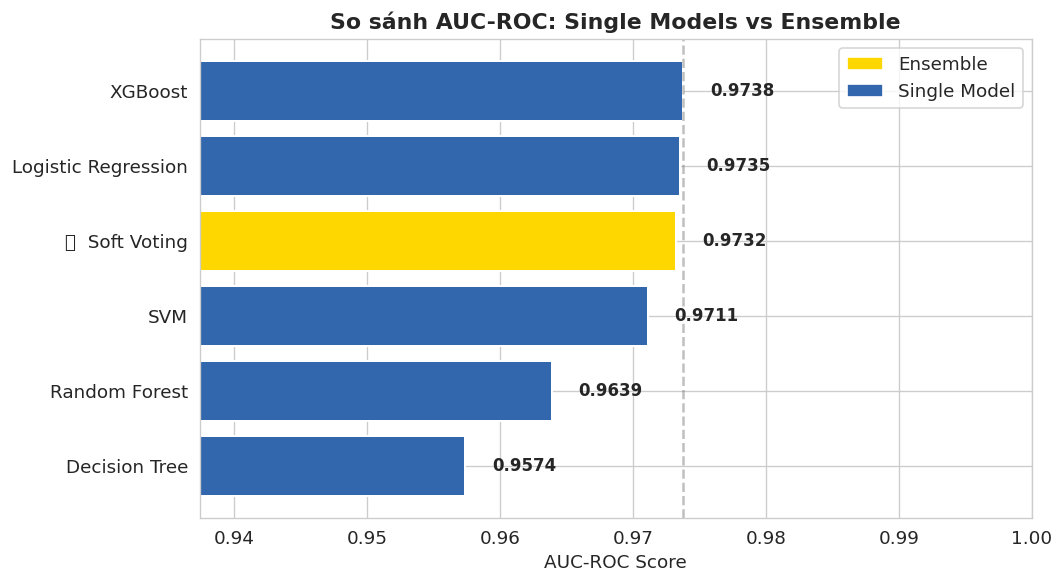

In [13]:
def plot_final_comparison_bar(df_comparison):
    """Bar chart so sánh AUC-ROC của tất cả models."""
    df_plot = df_comparison.sort_values('AUC-ROC')
    colors = ['#ffd700' if '🗳️' in idx else COLORS['accent']
              for idx in df_plot.index]

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(df_plot.index, df_plot['AUC-ROC'],
                   color=colors, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, df_plot['AUC-ROC']):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontweight='bold', fontsize=10)

    ax.set_xlabel('AUC-ROC Score', fontsize=11)
    ax.set_title('So sánh AUC-ROC: Single Models vs Ensemble', fontweight='bold')
    ax.set_xlim(df_plot['AUC-ROC'].min() - 0.02, 1.0)
    ax.axvline(x=df_comparison[~df_comparison.index.str.contains('🗳️')]['AUC-ROC'].max(),
               color='gray', linestyle='--', alpha=0.5, label='Best single model')
    ax.legend()

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#ffd700', label='Ensemble'),
        Patch(facecolor=COLORS['accent'], label='Single Model')
    ]
    ax.legend(handles=legend_elements)
    plt.tight_layout()
    plt.savefig('final_comparison.png', bbox_inches='tight')
    plt.show()

plot_final_comparison_bar(final_comparison)

## 🔍 Pha 7 — Giải Thích Mô Hình với SHAP

Đang tính SHAP values cho XGBoost...


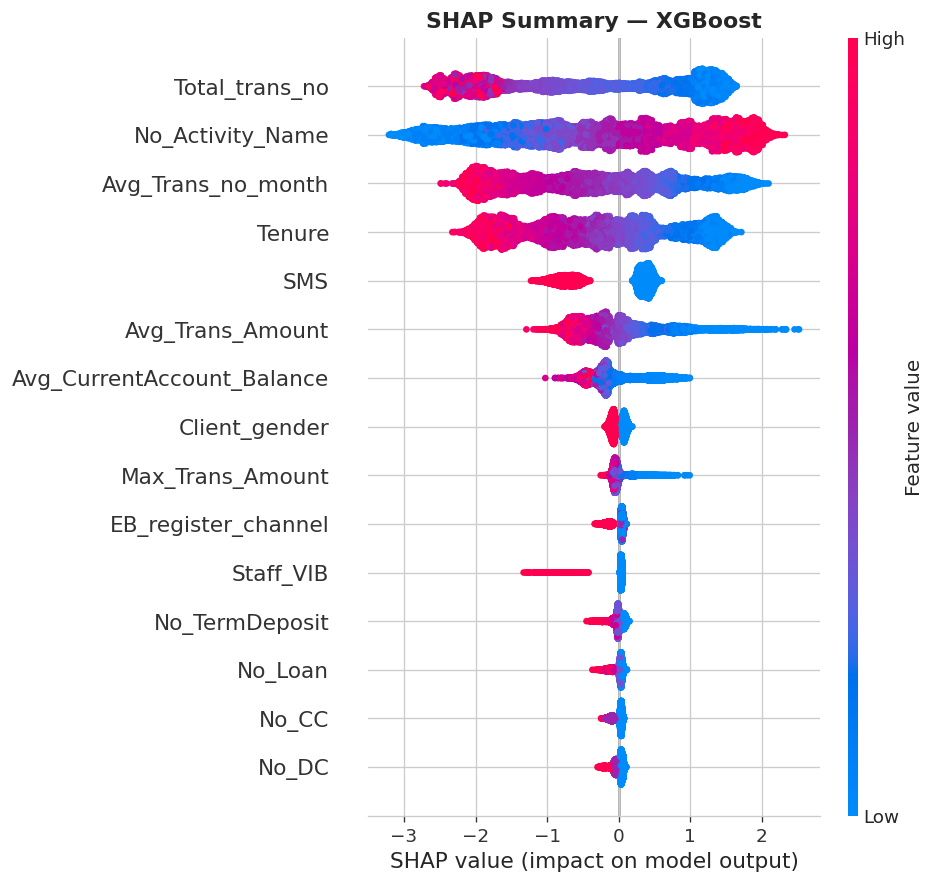

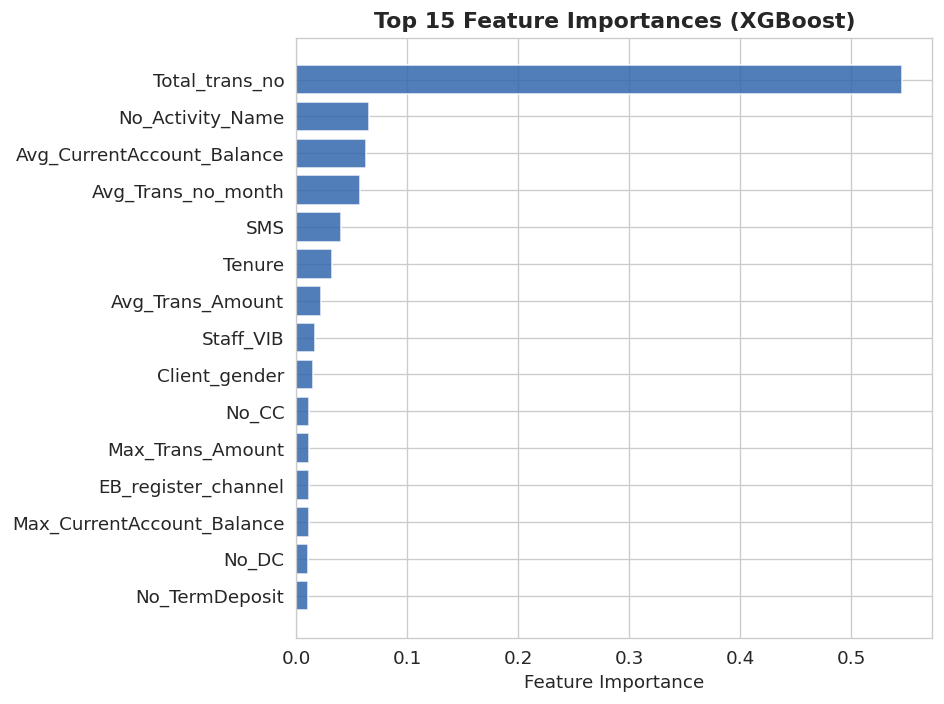

In [14]:
def plot_shap_summary(model, X_test, feature_names, model_name='XGBoost'):
    """SHAP beeswarm plot — tầm quan trọng và chiều ảnh hưởng của features."""
    print(f'Đang tính SHAP values cho {model_name}...')
    X_df = pd.DataFrame(X_test, columns=feature_names)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_df)

    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values, X_df, show=False, max_display=15)
    plt.title(f'SHAP Summary — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_summary.png', bbox_inches='tight')
    plt.show()
    return explainer, shap_values

def plot_feature_importance(model, feature_names, top_n=15):
    """Feature importance từ tree-based model."""
    importances = model.feature_importances_
    indices = np.argsort(importances)[-top_n:]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(range(top_n), importances[indices],
            color=COLORS['accent'], alpha=0.85, edgecolor='white')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_names[i] for i in indices])
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top {top_n} Feature Importances (XGBoost)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance.png', bbox_inches='tight')
    plt.show()

def explain_single_prediction(explainer, model, X_sample, feature_names, idx=0):
    """Giải thích dự đoán cho 1 khách hàng cụ thể."""
    X_df = pd.DataFrame(X_sample, columns=feature_names)
    shap_vals = explainer.shap_values(X_df)
    pred_prob = model.predict_proba(X_sample[idx:idx+1])[0][1]

    print(f'\n👤 Khách hàng #{idx}: Xác suất churn = {pred_prob:.1%}')
    print('Prediction:', '⚠️  CHURN' if pred_prob > 0.5 else '✅ KHÔNG CHURN')

    plt.figure(figsize=(10, 4))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals[idx],
            base_values=explainer.expected_value,
            data=X_df.iloc[idx].values,
            feature_names=feature_names
        ), show=False
    )
    plt.title(f'SHAP Waterfall — Khách hàng #{idx} (P(churn)={pred_prob:.1%})',
              fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_waterfall_{idx}.png', bbox_inches='tight')
    plt.show()

# Dùng XGBoost làm model chính để giải thích
xgb_model = trained_models['XGBoost']
feature_names = X.columns # Define feature_names
explainer, shap_values = plot_shap_summary(xgb_model, X_test, feature_names, 'XGBoost')
plot_feature_importance(xgb_model, feature_names, top_n=15)


👤 Khách hàng #3: Xác suất churn = 99.8%
Prediction: ⚠️  CHURN


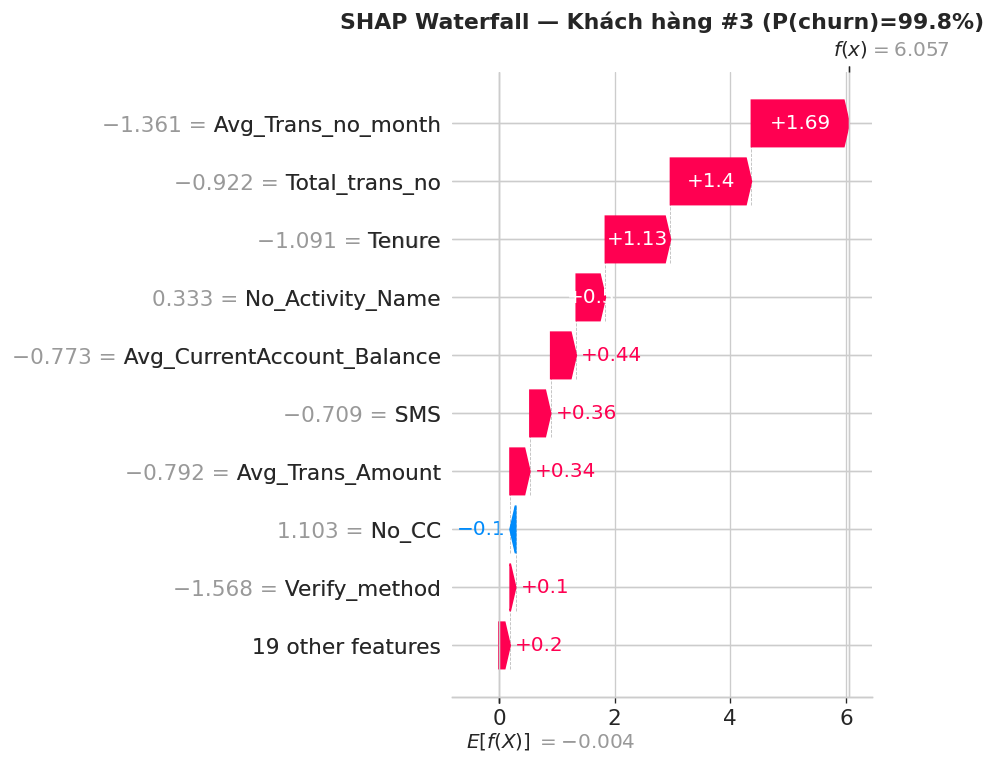


👤 Khách hàng #0: Xác suất churn = 0.1%
Prediction: ✅ KHÔNG CHURN


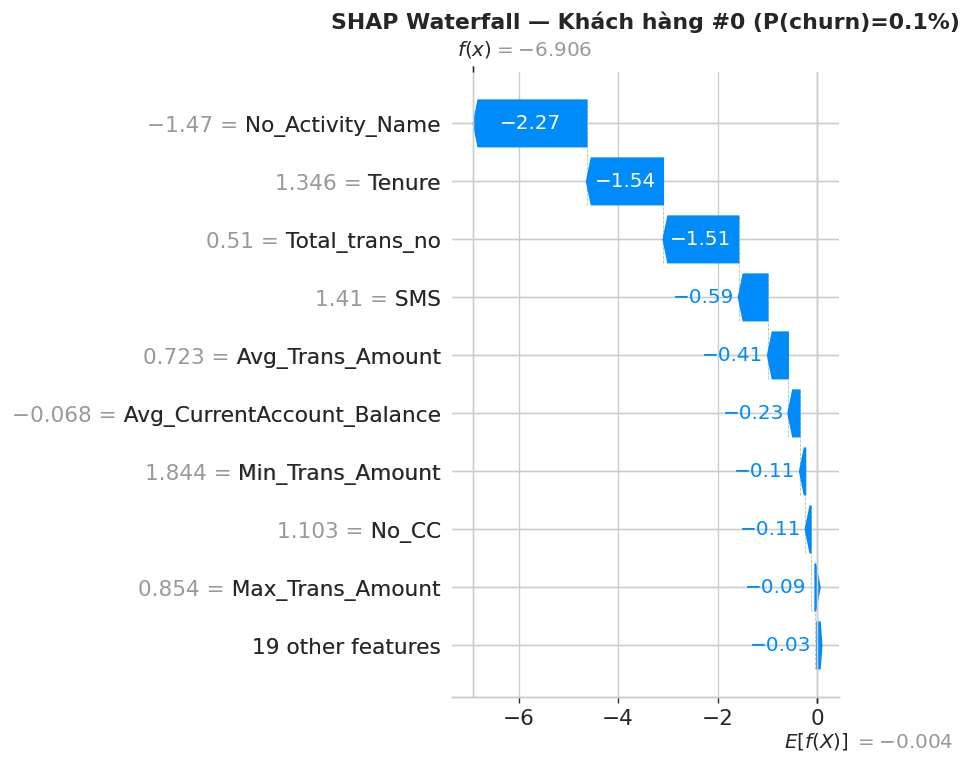

In [15]:
# Giải thích dự đoán cho 2 khách hàng cụ thể
# Tìm 1 khách hàng churn thật và 1 không churn
y_test_arr = np.array(y_test)
churn_idx    = np.where(y_test_arr == 1)[0][0]
no_churn_idx = np.where(y_test_arr == 0)[0][0]

explain_single_prediction(explainer, xgb_model, X_test, feature_names, idx=churn_idx)
explain_single_prediction(explainer, xgb_model, X_test, feature_names, idx=no_churn_idx)

## 💾 Pha 8 — Lưu Model & Dự Đoán Khách Hàng Mới

In [16]:
def save_model(model, scaler, path='best_model.pkl'):
    """Lưu model + scaler vào 1 file."""
    joblib.dump({'model': model, 'scaler': scaler}, path)
    print(f'✅ Đã lưu model: {path}')

def load_model(path='best_model.pkl'):
    """Load model từ file."""
    obj = joblib.load(path)
    return obj['model'], obj['scaler']

# Chọn model tốt nhất (Soft Voting hoặc XGBoost)
best_model_name = final_comparison.index[0]
print(f'🏆 Model tốt nhất: {best_model_name}')

all_models_combined = {**trained_models, **ensemble_models}
best_model = all_models_combined[best_model_name]
save_model(best_model, scaler, 'best_churn_model.pkl')

🏆 Model tốt nhất: XGBoost
✅ Đã lưu model: best_churn_model.pkl


  Kết quả dự đoán: CHURN ⚠️
  Xác suất rời bỏ: 98.5%


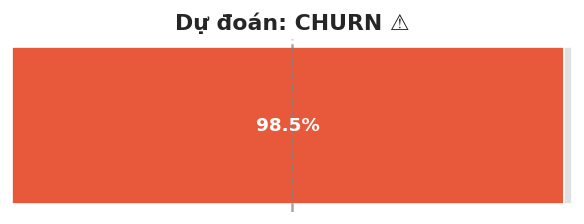

In [17]:
def predict_new_customer(model, scaler, feature_names, customer_dict):
    """
    Dự đoán 1 khách hàng mới.
    customer_dict: dict với keys là feature names (đã encode số),
                   đảm bảo đúng thứ tự feature_names.
    """
    X_new = pd.DataFrame([customer_dict])[feature_names]
    X_new_sc = scaler.transform(X_new)
    prob = model.predict_proba(X_new_sc)[0][1]
    pred = 'CHURN ⚠️' if prob > 0.5 else 'KHÔNG CHURN ✅'

    print('=' * 45)
    print(f'  Kết quả dự đoán: {pred}')
    print(f'  Xác suất rời bỏ: {prob:.1%}')
    print('=' * 45)

    # Bar chart xác suất
    fig, ax = plt.subplots(figsize=(5, 2))
    color = COLORS['churn'] if prob > 0.5 else COLORS['no_churn']
    ax.barh(['Xác suất churn'], [prob], color=color, height=0.4)
    ax.barh(['Xác suất churn'], [1 - prob], left=[prob],
            color='#e0e0e0', height=0.4)
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7)
    ax.text(prob/2, 0, f'{prob:.1%}', ha='center', va='center',
            color='white', fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_title(f'Dự đoán: {pred}', fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    return prob

# -------------------------------------------------------
# VÍ DỤ: khách hàng mới — thay các giá trị theo nhu cầu
# Sử dụng cột từ X_train_raw.iloc[0] làm ví dụ.
# -------------------------------------------------------

new_customer = {
    'Client_gender': 1.0,
    'Age': 39.89066030999999,
    'Staff_VIB': 0.0,
    'Tenure': 6.844440810000001,
    'SMS': 0.0,
    'Verify_method': 0.0,
    'EB_register_channel': 0.0,
    'No_Activity_Name': 11.0,
    'Type_Transactions': 3.0,
    'Total_trans_no': 20.0,
    'Avg_Trans_no_month': 1.5,
    'Avg_Trans_Amount': 5000000.0,
    'Max_Trans_Amount': 10000000.0,
    'Min_Trans_Amount': 100000.0,
    'No_CurrentAccount': 1.0,
    'Avg_CurrentAccount_Balance': 20000000.0,
    'Max_CurrentAccount_Balance': 30000000.0,
    'Min_CurrentAccount_Balance': 5000000.0,
    'No_TermDeposit': 0.0,
    'Avg_TermDeposit_Balance': 0.0,
    'Max_TermDeposit_Balance': 0.0,
    'Min_TermDeposit_Balance': 0.0,
    'No_Loan': 0.0,
    'Avg_Loan_Balance': 0.0,
    'Max_Loan_Balance': 0.0,
    'Min_Loan_Balance': 0.0,
    'No_CC': 1.0,
    'No_DC': 1.0
}

prob = predict_new_customer(best_model, scaler, feature_names, new_customer)

In [18]:
# ============================================================
# TỔNG KẾT PROJECT
# ============================================================
print('\n' + '='*55)
print('   TỔNG KẾT — CHURN PREDICTION PROJECT')
print('='*55)

best_metrics = evaluate_model(best_model, X_test, y_test, best_model_name)
print(f'  Model tốt nhất   : {best_model_name}')
print(f'  AUC-ROC          : {best_metrics["AUC-ROC"]}')
print(f'  F1-Score         : {best_metrics["F1"]}')
print(f'  Recall (churn)   : {best_metrics["Recall"]} ')
print(f'  Precision        : {best_metrics["Precision"]}')
print(f'  Accuracy         : {best_metrics["Accuracy"]}')
print('='*55)


   TỔNG KẾT — CHURN PREDICTION PROJECT
  Model tốt nhất   : XGBoost
  AUC-ROC          : 0.9738
  F1-Score         : 0.8752
  Recall (churn)   : 0.9022 
  Precision        : 0.8498
  Accuracy         : 0.9099


In [19]:
import joblib
from google.colab import files

# Lưu model + scaler vào 1 file
joblib.dump({'model': best_model, 'scaler': scaler},
            'best_churn_model.pkl')

# Tải về máy tự động
files.download('best_churn_model.pkl')
print('✅ Đã tải xong!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Đã tải xong!
